# SFT Results

Run all cells to generate paper figures and full results for all dataset/task combinations.

In [10]:
import json
import os
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [11]:
# ============================================
# Configuration (5 settings; Full-FT focus)
# ============================================
SCRATCH_DIR = "/work/hdd/bfwm/phu1/Project"
out_dir = f"{SCRATCH_DIR}/Dr.Post-Training/SFT"
config_base = './train/configs'
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

default_model = 'meta-llama/Llama-3.2-1B'

def _model_short(hf_name):
    return hf_name.split('/')[-1]

DATASETS = [
    {'config': 'alpaca_samsum',  'train': 'alpaca',   'task': 'samsum',  'percentage': 0.4,   'model': 'meta-llama/Llama-3.2-1B'},
    {'config': 'tulu3_tydiqa',   'train': 'tulu3',    'task': 'tydiqa',  'percentage': 0.01,  'model': 'meta-llama/Llama-3.2-1B'},
    {'config': 'less_tydiqa',    'train': 'less',     'task': 'tydiqa',  'percentage': 0.005, 'model': 'meta-llama/Llama-3.2-1B'},
    {'config': 'triviaqa_nq',    'train': 'triviaqa', 'task': 'nq_open', 'percentage': 0.064, 'model': 'meta-llama/Llama-3.2-1B', 'y_clip_max': 10.0},
    {'config': 'nq_squad',       'train': 'nq_open',  'task': 'squad',   'percentage': 0.1,   'model': 'meta-llama/Llama-3.2-1B', 'y_clip_max': 10.0},
]

SHARED_CONFIG = {'batch_size': 8, 'n_val': 16}

ALL_METHODS = [
    'FullTraining-Full',
    'GlobalSubset-Full',
    'LayerWiseSubset-Full',
]

FINETUNING_GROUPS = {
    'Full': ['FullTraining-Full', 'GlobalSubset-Full', 'LayerWiseSubset-Full'],
}
FT_ORDER = ['Full']

DATASET_TITLES = {
    'alpaca_samsum':  'SAMSUM',
    'tulu3_tydiqa':   'TYDIQA (Tulu3 pool)',
    'less_tydiqa':    'TYDIQA (LESS pool)',
    'triviaqa_nq':    'NQ-open (TriviaQA pool)',
    'nq_squad':       'SQuAD closed-book (NQ pool)',
}

LEGEND_NAMES = {
    'FullTraining-Full':    'Full-Training',
    'LayerWiseSubset-Full': 'Layer-Wise Subset',
    'GlobalSubset-Full':    'Global Subset',
}

METHOD_COLORS = {
    'FullTraining-Full':    'black',
    'LayerWiseSubset-Full': 'red',
    'GlobalSubset-Full':    'green',
}

TASK_METRICS = {
    'samsum': {
        'result_file': 'samsum_results.json',
        'metrics': ['rouge1', 'rouge2', 'rougeL'],
        'display_names': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
        'primary_metric': 'rougeL',
        'format': lambda x: f"{x:.3f}" if x is not None else 'N/A',
    },
    'tydiqa': {
        'result_file': 'tydiqa_results.json',
        'metrics': ['f1_score', 'exact_match'],
        'display_names': ['F1 Score', 'Exact Match'],
        'primary_metric': 'f1_score',
        'format': lambda x: f"{x:.2f}" if x is not None else 'N/A',
    },
    'nq_open': {
        'result_file': 'nq_open_results.json',
        'metrics': ['em', 'f1'],
        'display_names': ['EM', 'F1'],
        'primary_metric': 'em',
        'format': lambda x: f"{x:.3f}" if x is not None else 'N/A',
    },
    'squad': {
        'result_file': 'squad_results.json',
        'metrics': ['em', 'f1'],
        'display_names': ['EM', 'F1'],
        'primary_metric': 'em',
        'format': lambda x: f"{x:.3f}" if x is not None else 'N/A',
    },
}

VAL_ABLATION = [
    {'main_ds_key': 'alpaca_samsum',  'task': 'samsum',  'max_steps': 2600, 'batch_size': 8, 'n_val': 16, 'config': 'alpaca_samsum',  'model': 'meta-llama/Llama-3.2-1B'},
    {'main_ds_key': 'tulu3_tydiqa',   'task': 'tydiqa',  'max_steps': 1174, 'batch_size': 8, 'n_val': 16, 'config': 'tulu3_tydiqa',   'model': 'meta-llama/Llama-3.2-1B'},
    {'main_ds_key': 'less_tydiqa',    'task': 'tydiqa',  'max_steps': 1225, 'batch_size': 8, 'n_val': 16, 'config': 'less_tydiqa',    'model': 'meta-llama/Llama-3.2-1B'},
    {'main_ds_key': 'triviaqa_nq',    'task': 'nq_open', 'max_steps': 1100, 'batch_size': 8, 'n_val': 16, 'config': 'triviaqa_nq',    'model': 'meta-llama/Llama-3.2-1B', 'y_clip_max': 100.0},
    {'main_ds_key': 'nq_squad',       'task': 'squad',   'max_steps': 1100, 'batch_size': 8, 'n_val': 16, 'config': 'nq_squad',       'model': 'meta-llama/Llama-3.2-1B', 'y_clip_max': 100.0},
]
VAL_ABLATION_METHODS = ['FullTraining-Full']

def load_lr_from_yaml(config_name, method_name):
    method_yaml = os.path.join(config_base, config_name, f"{method_name}.yaml")
    if os.path.exists(method_yaml):
        with open(method_yaml, 'r') as f:
            cfg = yaml.safe_load(f)
        if cfg and 'learning_rate' in cfg:
            return cfg['learning_rate']
    defaults_yaml = os.path.join(config_base, config_name, 'defaults.yaml')
    if os.path.exists(defaults_yaml):
        with open(defaults_yaml, 'r') as f:
            cfg = yaml.safe_load(f)
        if cfg and 'learning_rate' in cfg:
            return cfg['learning_rate']
    return None

def load_target_only_lr(config_name, ft='Full'):
    parts = ['Target-only']
    if ft != 'Full':
        parts.append(ft)
    parts.append('lr.txt')
    fname = '.'.join(parts)
    p = os.path.join(config_base, config_name, fname)
    if os.path.exists(p):
        with open(p) as f:
            return f.read().strip()
    return None

lr_config = {}
for ds in DATASETS:
    ds_key = ds['config']
    lr_config[ds_key] = {}
    for method in ALL_METHODS:
        lr = load_lr_from_yaml(ds_key, method)
        if lr is not None:
            lr_config[ds_key][method] = lr

print(f"Datasets ({len(DATASETS)}):")
for ds in DATASETS:
    print(f"  {ds['config']}: {ds['train']} -> {ds['task']} ({_model_short(ds['model'])})")
print(f"Methods: {len(ALL_METHODS)} (Full-FT only)")
print(f"\nMain-run LRs:")
for ds_key, methods in lr_config.items():
    print(f"  {ds_key}:")
    for m, lr in methods.items():
        print(f"    {m}: {lr}")
print(f"\nTarget-only LRs:")
for va in VAL_ABLATION:
    lr = load_target_only_lr(va['config'], 'Full')
    print(f"  {va['main_ds_key']}: {lr}")


Datasets (5):
  alpaca_samsum: alpaca -> samsum (Llama-3.2-1B)
  tulu3_tydiqa: tulu3 -> tydiqa (Llama-3.2-1B)
  less_tydiqa: less -> tydiqa (Llama-3.2-1B)
  triviaqa_nq: triviaqa -> nq_open (Llama-3.2-1B)
  nq_squad: nq_open -> squad (Llama-3.2-1B)
Methods: 3 (Full-FT only)

Main-run LRs:
  alpaca_samsum:
    FullTraining-Full: 1e-06
    GlobalSubset-Full: 1.83e-06
    LayerWiseSubset-Full: 1.27e-05
  tulu3_tydiqa:
    FullTraining-Full: 4e-05
    GlobalSubset-Full: 2e-05
    LayerWiseSubset-Full: 3.36e-05
  less_tydiqa:
    FullTraining-Full: 5e-05
    GlobalSubset-Full: 5e-05
    LayerWiseSubset-Full: 5e-05
  triviaqa_nq:
    FullTraining-Full: 1.27e-05
    GlobalSubset-Full: 7.85e-06
    LayerWiseSubset-Full: 1.27e-05
  nq_squad:
    FullTraining-Full: 1.27e-05
    GlobalSubset-Full: 1.27e-05
    LayerWiseSubset-Full: 7.85e-06

Target-only LRs:
  alpaca_samsum: 6.95e-07
  tulu3_tydiqa: 4.83e-06
  less_tydiqa: 5.00e-05
  triviaqa_nq: 6.95e-07
  nq_squad: 6.95e-07


## Helper Functions & Load All Data

In [12]:
# ============================================
# Helper functions (per-ds model)
# ============================================

def _finetuning_type(name):
    return name.split('-', 1)[1]

def _format_lr(lr_val):
    """Format LR value to match directory naming convention."""
    if lr_val is None:
        return '5e-05'
    lr_val = float(lr_val)
    if lr_val < 0.001:
        return f'{lr_val:.2e}'
    else:
        return f'{lr_val}'

def _lookup_lr(method_name, ds):
    """Look up LR by config dir name (ds['config'])."""
    key = ds['config']
    if key in lr_config and method_name in lr_config[key]:
        return _format_lr(lr_config[key][method_name])
    ft = _finetuning_type(method_name)
    return '2e-04' if ft == 'LoRA' else '5e-05'

def _dir_name(method_name, seed, ds):
    """Build experiment directory name. Run dir prefix is {train}_{task}-{model_short}."""
    lr = _lookup_lr(method_name, ds)
    cfg = SHARED_CONFIG
    model_short = _model_short(ds.get('model', default_model))
    return (f"{ds['train']}_{ds['task']}-{model_short}-{method_name}"
            f"-p{ds['percentage']}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{seed}")

def _discover_seeds(method_name, ds):
    pattern = _dir_name(method_name, '*', ds)
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def _load_eval_results(path):
    with open(path, 'r') as f:
        data = json.load(f)
    steps = [item['step'] for item in data]
    val_ppl = [item['val_perplexity'] for item in data]
    eval_ppl = [item['eval_perplexity'] for item in data]
    wt = [item.get('wall_time') for item in data]
    twt = [item.get('train_wall_time', item.get('wall_time')) for item in data]
    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_ppl),
        'eval_perplexity': np.array(eval_ppl),
        'wall_time': np.array(wt) if all(t is not None for t in wt) else None,
        'train_wall_time': np.array(twt) if all(t is not None for t in twt) else None,
    }

def load_method_results(method_name, ds):
    seeds = _discover_seeds(method_name, ds)
    if not seeds:
        return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_dir_name(method_name, seed, ds)}/evaluation_results.json"
        if Path(path).exists():
            all_res.append(_load_eval_results(path))
            valid_seeds.append(seed)
    if not all_res:
        return None
    n_seeds = len(valid_seeds)
    se = np.sqrt(n_seeds)
    min_len = min(len(r['steps']) for r in all_res)
    steps = all_res[0]['steps'][:min_len]
    val_ppl = np.stack([r['val_perplexity'][:min_len] for r in all_res])
    eval_ppl = np.stack([r['eval_perplexity'][:min_len] for r in all_res])
    wts = [r['wall_time'] for r in all_res if r['wall_time'] is not None]
    if len(wts) == len(all_res):
        wt = np.stack([w[:min_len] for w in wts])
        wt_mean, wt_std = np.mean(wt, axis=0), np.std(wt, axis=0) / se
    else:
        wt_mean = wt_std = None
    twts = [r['train_wall_time'] for r in all_res if r['train_wall_time'] is not None]
    if len(twts) == len(all_res):
        twt = np.stack([w[:min_len] for w in twts])
        twt_mean, twt_std = np.mean(twt, axis=0), np.std(twt, axis=0) / se
    else:
        twt_mean = twt_std = None
    return {
        'steps': steps,
        'val_perplexity_mean': np.mean(val_ppl, axis=0), 'val_perplexity_std': np.std(val_ppl, axis=0) / se,
        'eval_perplexity_mean': np.mean(eval_ppl, axis=0), 'eval_perplexity_std': np.std(eval_ppl, axis=0) / se,
        'wall_time_mean': wt_mean, 'wall_time_std': wt_std,
        'train_wall_time_mean': twt_mean, 'train_wall_time_std': twt_std,
        'n_seeds': n_seeds, 'seeds': valid_seeds,
    }

def load_task_metric(method_name, ds, seeds):
    task = ds['task']
    if task not in TASK_METRICS:
        return None
    result_file = TASK_METRICS[task]['result_file']
    seed_results, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_dir_name(method_name, seed, ds)}/{result_file}"
        if Path(path).exists():
            with open(path, 'r') as f:
                seed_results.append(json.load(f))
                valid_seeds.append(seed)
    if not seed_results:
        return None
    aggregated = {'seeds': valid_seeds, 'n_seeds': len(valid_seeds)}
    for metric in TASK_METRICS[task]['metrics']:
        values = [r.get(metric) for r in seed_results if r.get(metric) is not None]
        if values:
            aggregated[f'{metric}_mean'] = np.mean(values)
            aggregated[f'{metric}_std'] = np.std(values) / np.sqrt(len(values))
        else:
            aggregated[f'{metric}_mean'] = None
            aggregated[f'{metric}_std'] = None
    return aggregated


# ============================================
# Load all main-run data (keyed by config dir name)
# ============================================
all_results = {}
all_task_results = {}

for ds in DATASETS:
    ds_key = ds['config']
    print(f"\n{'='*60}")
    print(f"Loading: {ds_key} ({_model_short(ds['model'])})")
    print(f"{'='*60}")

    results = {}
    task_results = {}

    for method_name in ALL_METHODS:
        pattern = _dir_name(method_name, '*', ds)
        seeds = _discover_seeds(method_name, ds)
        data = load_method_results(method_name, ds)
        if data:
            results[method_name] = data
            print(f"  + {method_name}: {data['n_seeds']} seeds, {len(data['steps'])} points", end="")
        elif seeds:
            print(f"  ~ {method_name}: {len(seeds)} seeds (no training curves)", end="")
        else:
            print(f"  - {method_name}: Not found ({pattern})")
            continue
        tdata = load_task_metric(method_name, ds, seeds)
        if tdata:
            task_results[method_name] = tdata
            print(f", task metrics: {tdata['n_seeds']} seeds")
        else:
            print()

    all_results[ds_key] = results
    all_task_results[ds_key] = task_results
    print(f"  Loaded {len(results)}/{len(ALL_METHODS)} training, {len(task_results)} task-specific")

print(f"\n{'='*60}")
print(f"All data loaded: {list(all_results.keys())}")
print(f"{'='*60}")



Loading: alpaca_samsum (Llama-3.2-1B)
  + FullTraining-Full: 5 seeds, 103 points, task metrics: 5 seeds
  + GlobalSubset-Full: 5 seeds, 103 points, task metrics: 5 seeds
  + LayerWiseSubset-Full: 5 seeds, 103 points, task metrics: 5 seeds
  Loaded 3/3 training, 3 task-specific

Loading: tulu3_tydiqa (Llama-3.2-1B)
  + FullTraining-Full: 5 seeds, 99 points, task metrics: 5 seeds
  + GlobalSubset-Full: 5 seeds, 99 points, task metrics: 5 seeds
  + LayerWiseSubset-Full: 5 seeds, 99 points, task metrics: 5 seeds
  Loaded 3/3 training, 3 task-specific

Loading: less_tydiqa (Llama-3.2-1B)
  - FullTraining-Full: Not found (less_tydiqa-Llama-3.2-1B-FullTraining-Full-p0.005-lr5.00e-05-b8-v16-s*)
  - GlobalSubset-Full: Not found (less_tydiqa-Llama-3.2-1B-GlobalSubset-Full-p0.005-lr5.00e-05-b8-v16-s*)
  - LayerWiseSubset-Full: Not found (less_tydiqa-Llama-3.2-1B-LayerWiseSubset-Full-p0.005-lr5.00e-05-b8-v16-s*)
  Loaded 0/3 training, 0 task-specific

Loading: triviaqa_nq (Llama-3.2-1B)
  + FullT

In [13]:
# ============================================
# Val-ablation loader (per-va model)
# ============================================

def _val_ablation_dir_name(method_name, seed, va):
    ft = method_name.split('-', 1)[1]
    raw_lr = load_target_only_lr(va['config'], ft)
    if raw_lr is None:
        return None
    lr = _format_lr(raw_lr)
    bs = va.get('batch_size', 8)
    nv = va.get('n_val', 16)
    task = va['task']
    model_short = _model_short(va.get('model', default_model))
    return (f"{task}_val_{task}-{model_short}-{method_name}"
            f"-ms{va['max_steps']}-lr{lr}-b{bs}-v{nv}-s{seed}")

def _discover_val_ablation_seeds(method_name, va):
    pattern = _val_ablation_dir_name(method_name, '*', va)
    if pattern is None:
        return []
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def load_val_ablation_results(method_name, va):
    seeds = _discover_val_ablation_seeds(method_name, va)
    if not seeds:
        return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_val_ablation_dir_name(method_name, seed, va)}/evaluation_results.json"
        if Path(path).exists():
            all_res.append(_load_eval_results(path))
            valid_seeds.append(seed)
    if not all_res:
        return None
    n_seeds = len(valid_seeds)
    se = np.sqrt(n_seeds)
    min_len = min(len(r['steps']) for r in all_res)
    steps = all_res[0]['steps'][:min_len]
    val_ppl = np.stack([r['val_perplexity'][:min_len] for r in all_res])
    eval_ppl = np.stack([r['eval_perplexity'][:min_len] for r in all_res])
    wts = [r['wall_time'] for r in all_res if r['wall_time'] is not None]
    wt_mean = wt_std = None
    if len(wts) == len(all_res):
        wt = np.stack([w[:min_len] for w in wts])
        wt_mean, wt_std = np.mean(wt, axis=0), np.std(wt, axis=0) / se
    twts = [r['train_wall_time'] for r in all_res if r['train_wall_time'] is not None]
    twt_mean = twt_std = None
    if len(twts) == len(all_res):
        twt = np.stack([w[:min_len] for w in twts])
        twt_mean, twt_std = np.mean(twt, axis=0), np.std(twt, axis=0) / se
    return {
        'steps': steps,
        'val_perplexity_mean': np.mean(val_ppl, axis=0), 'val_perplexity_std': np.std(val_ppl, axis=0) / se,
        'eval_perplexity_mean': np.mean(eval_ppl, axis=0), 'eval_perplexity_std': np.std(eval_ppl, axis=0) / se,
        'wall_time_mean': wt_mean, 'wall_time_std': wt_std,
        'train_wall_time_mean': twt_mean, 'train_wall_time_std': twt_std,
        'n_seeds': n_seeds, 'seeds': valid_seeds,
    }

def load_val_ablation_task_metric(method_name, va, seeds):
    task = va['task']
    if task not in TASK_METRICS:
        return None
    result_file = TASK_METRICS[task]['result_file']
    seed_results, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_val_ablation_dir_name(method_name, seed, va)}/{result_file}"
        if Path(path).exists():
            with open(path, 'r') as f:
                seed_results.append(json.load(f))
                valid_seeds.append(seed)
    if not seed_results:
        return None
    aggregated = {'seeds': valid_seeds, 'n_seeds': len(valid_seeds)}
    for metric in TASK_METRICS[task]['metrics']:
        values = [r.get(metric) for r in seed_results if r.get(metric) is not None]
        if values:
            aggregated[f'{metric}_mean'] = np.mean(values)
            aggregated[f'{metric}_std'] = np.std(values) / np.sqrt(len(values))
        else:
            aggregated[f'{metric}_mean'] = None
            aggregated[f'{metric}_std'] = None
    return aggregated

# Load val-ablation data keyed by main_ds_key (== config dir name of the main setting)
val_ablation_results = {}
val_ablation_task_results = {}

for va in VAL_ABLATION:
    ds_key = va['main_ds_key']
    print(f"\n{'='*60}")
    print(f"Loading val-ablation for {ds_key}")
    print(f"{'='*60}")
    results = {}
    task_results = {}
    for method_name in VAL_ABLATION_METHODS:
        data = load_val_ablation_results(method_name, va)
        if data:
            results[method_name] = data
            seeds = data['seeds']
            print(f"  + {method_name}: {data['n_seeds']} seeds, {len(data['steps'])} points")
            tdata = load_val_ablation_task_metric(method_name, va, seeds)
            if tdata:
                task_results[method_name] = tdata
                print(f"    task metrics: {[k for k in tdata if '_mean' in k]}")
        else:
            print(f"  - {method_name}: Not found")
    val_ablation_results[ds_key] = results
    val_ablation_task_results[ds_key] = task_results
    print(f"  Loaded {len(results)}/{len(VAL_ABLATION_METHODS)} training, {len(task_results)} task-specific")



Loading val-ablation for alpaca_samsum


  + FullTraining-Full: 5 seeds, 202 points
    task metrics: ['rouge1_mean', 'rouge2_mean', 'rougeL_mean']
  Loaded 1/1 training, 1 task-specific

Loading val-ablation for tulu3_tydiqa
  + FullTraining-Full: 5 seeds, 196 points
    task metrics: ['f1_score_mean', 'exact_match_mean']
  Loaded 1/1 training, 1 task-specific

Loading val-ablation for less_tydiqa
  - FullTraining-Full: Not found
  Loaded 0/1 training, 0 task-specific

Loading val-ablation for triviaqa_nq
  + FullTraining-Full: 3 seeds, 152 points
    task metrics: ['em_mean', 'f1_mean']
  Loaded 1/1 training, 1 task-specific

Loading val-ablation for nq_squad
  + FullTraining-Full: 3 seeds, 152 points
    task metrics: ['em_mean', 'f1_mean']
  Loaded 1/1 training, 1 task-specific


## Paper Figures: Eval Perplexity vs Step

One plot per (dataset, finetuning type). Each plot compares Full-Training vs Global Subset vs Layer-Wise Subset.


  alpaca_samsum

  [alpaca_samsum] Full: Eval Perplexity vs Step
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 5 seeds, final=5.8617
    + GlobalSubset-Full: 5 seeds, final=5.4364
    + LayerWiseSubset-Full: 5 seeds, final=5.1061
    -> Saved: ./figures/alpaca_samsum_Full.pdf


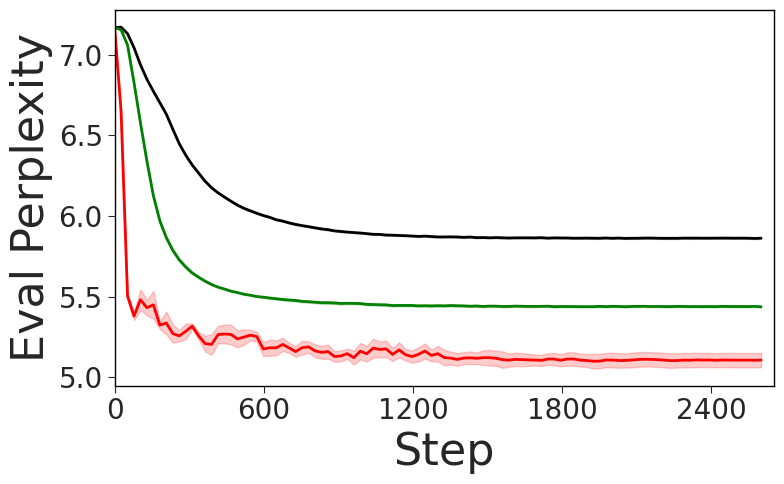


  tulu3_tydiqa

  [tulu3_tydiqa] Full: Eval Perplexity vs Step
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 5 seeds, final=2.2758
    + GlobalSubset-Full: 5 seeds, final=1.7552
    + LayerWiseSubset-Full: 5 seeds, final=1.6285
    -> Saved: ./figures/tulu3_tydiqa_Full.pdf


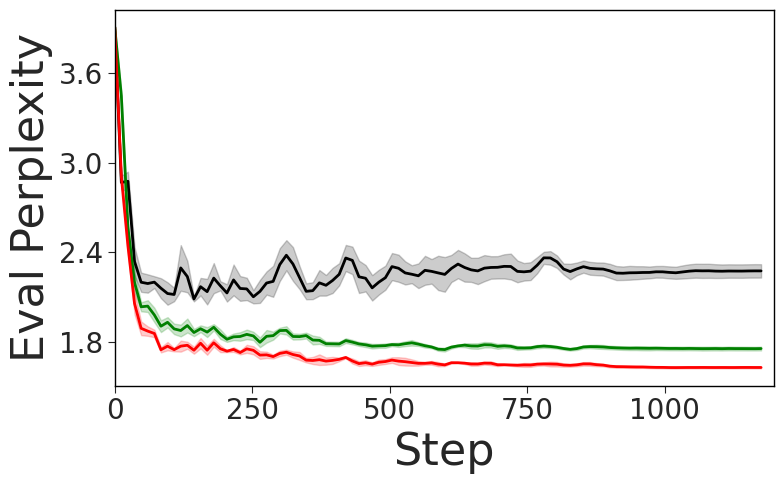


  less_tydiqa

  [less_tydiqa] Full: Eval Perplexity vs Step
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    - FullTraining-Full: no data
    - GlobalSubset-Full: no data
    - LayerWiseSubset-Full: no data
    -> Saved: ./figures/less_tydiqa_Full.pdf


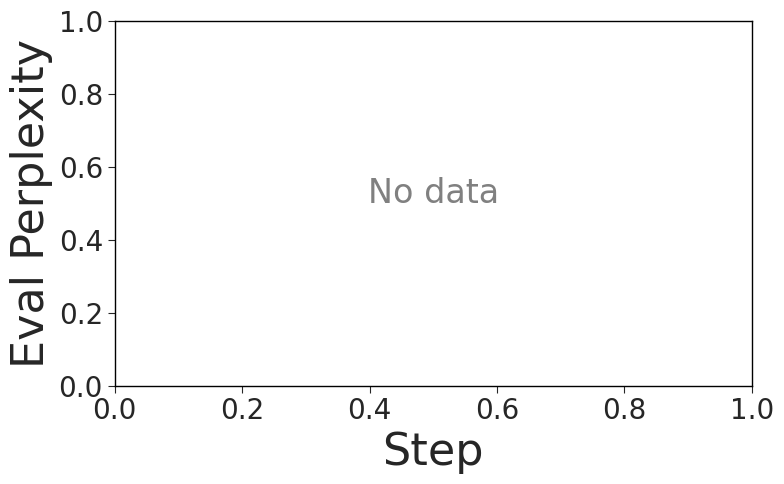


  triviaqa_nq

  [triviaqa_nq] Full: Eval Perplexity vs Step
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 3 seeds, final=11.2862
    + GlobalSubset-Full: 3 seeds, final=10.2603
    + LayerWiseSubset-Full: 3 seeds, final=10.5060
    -> Saved: ./figures/triviaqa_nq_Full.pdf


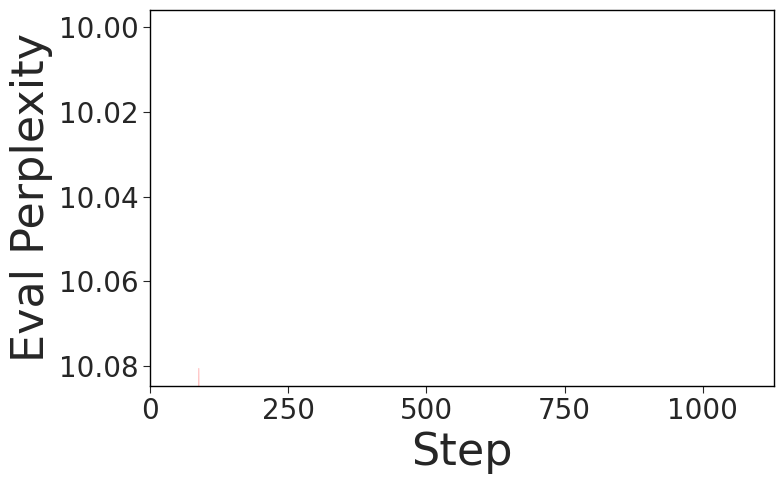


  nq_squad

  [nq_squad] Full: Eval Perplexity vs Step
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 3 seeds, final=6.9609
    + GlobalSubset-Full: 3 seeds, final=7.0653
    + LayerWiseSubset-Full: 3 seeds, final=7.1497
    -> Saved: ./figures/nq_squad_Full.pdf


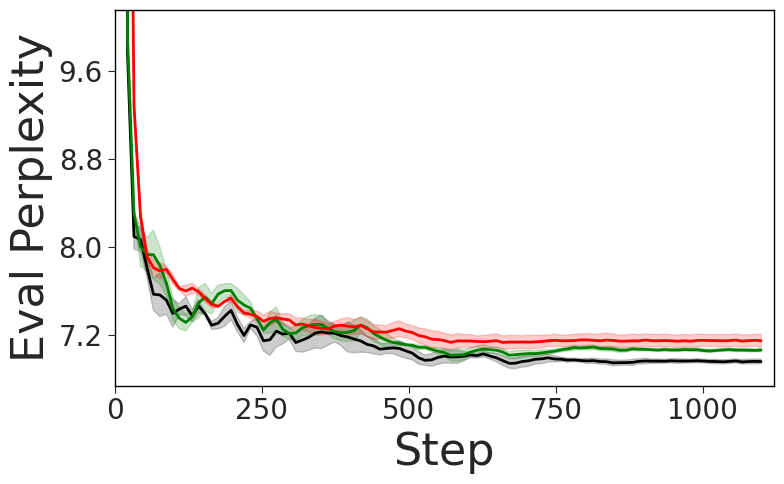


Saved legend: ./figures/legend.pdf


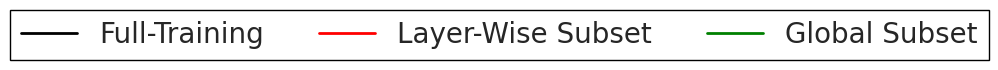

In [14]:
# Paper figures: one per (dataset, finetuning type)
# Each compares Full-Training vs Global Subset vs Layer-Wise Subset on eval perplexity vs training step

for ds in DATASETS:
    ds_key = ds['config']
    results = all_results[ds_key]

    print(f"\n{'='*60}")
    print(f"  {ds_key}")
    print(f"{'='*60}")

    # First pass: collect axis ranges across all finetuning groups for this dataset
    all_x_vals, all_y_mins, all_y_maxs = [], [], []
    for ft_name, ft_methods in FINETUNING_GROUPS.items():
        for method_name in ft_methods:
            if method_name not in results:
                continue
            data = results[method_name]
            all_x_vals.append(data['steps'])
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            if data['n_seeds'] > 1:
                all_y_mins.append((mean - std).min())
                all_y_maxs.append((mean + std).max())
            else:
                all_y_mins.append(mean.min())
                all_y_maxs.append(mean.max())

    if all_x_vals:
        shared_x_max = max(v.max() for v in all_x_vals)
        shared_y_min = min(all_y_mins)
        shared_y_max = max(all_y_maxs)
        # Per-dataset y-axis cap: clip outliers (e.g. step=0 baseline on TriviaQA)
        if ds.get('y_clip_max') is not None:
            shared_y_max = min(shared_y_max, ds['y_clip_max'])
        y_pad = (shared_y_max - shared_y_min) * 0.05
    else:
        shared_x_max = shared_y_min = shared_y_max = y_pad = None

    for ft_name, ft_methods in FINETUNING_GROUPS.items():
        print(f"\n  [{ds_key}] {ft_name}: Eval Perplexity vs Step")
        print(f"    Methods: {', '.join(LEGEND_NAMES.get(m, m) for m in ft_methods)}")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')

        has_data = False
        for method_name in ft_methods:
            if method_name not in results:
                print(f"    - {method_name}: no data")
                continue
            data = results[method_name]
            x = data['steps']
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            color = METHOD_COLORS.get(method_name)
            display = LEGEND_NAMES.get(method_name, method_name)

            ax.plot(x, mean, linewidth=2, label=display, color=color)
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
            has_data = True
            print(f"    + {method_name}: {data['n_seeds']} seeds, final={mean[-1]:.4f}")

        ax.set_xlabel('Step', fontsize=32)
        if ft_name == 'Full':
            ax.set_ylabel('Eval Perplexity', fontsize=32)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        # Enforce shared axis limits across finetuning groups for this dataset
        if shared_x_max is not None:
            ax.set_xlim(left=0, right=shared_x_max * 1.02)
            ax.set_ylim(shared_y_min - y_pad, shared_y_max + y_pad)

        if not has_data:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=24, color='gray')

        plt.tight_layout()
        filepath = os.path.join(save_dir, f"{ds_key}_{ft_name}.pdf")
        fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"    -> Saved: {filepath}")
        plt.show()

# Save a standalone legend figure
legend_labels = ['Full-Training', 'Layer-Wise Subset', 'Global Subset']
legend_colors = ['black', 'red', 'green']

fig_leg, ax_leg = plt.subplots(figsize=(6, 0.5))
ax_leg.set_axis_off()
handles = [plt.Line2D([0], [0], color=c, linewidth=2) for c in legend_colors]
legend = fig_leg.legend(handles, legend_labels, loc='center', ncol=len(legend_labels),
                        fontsize=20, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
fig_leg.patch.set_facecolor('white')
filepath = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"\nSaved legend: {filepath}")
plt.show()

## Paper Figures: Eval Perplexity vs Wall Time

One plot per (dataset, finetuning type). Each plot compares Full-Training vs Global Subset vs Layer-Wise Subset.


  alpaca_samsum

  [alpaca_samsum] Full: Eval Perplexity vs Wall Time
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 5 seeds, final=5.8617
    + GlobalSubset-Full: 5 seeds, final=5.4364
    + LayerWiseSubset-Full: 5 seeds, final=5.1061


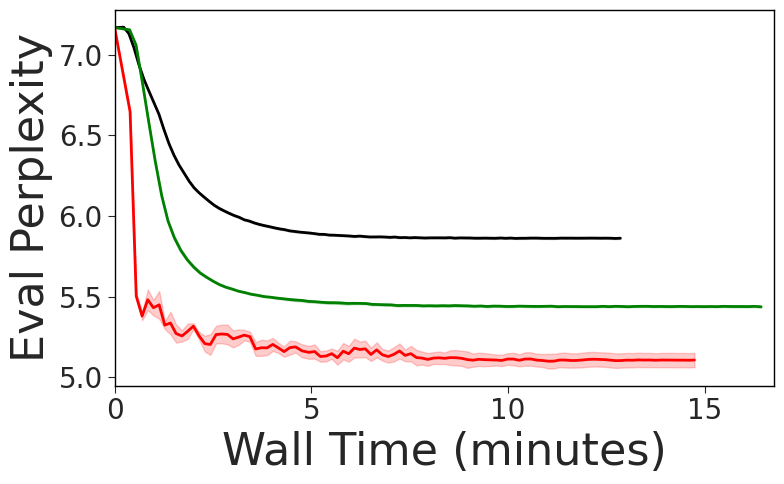


  tulu3_tydiqa

  [tulu3_tydiqa] Full: Eval Perplexity vs Wall Time
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 5 seeds, final=2.2758
    + GlobalSubset-Full: 5 seeds, final=1.7552
    + LayerWiseSubset-Full: 5 seeds, final=1.6285


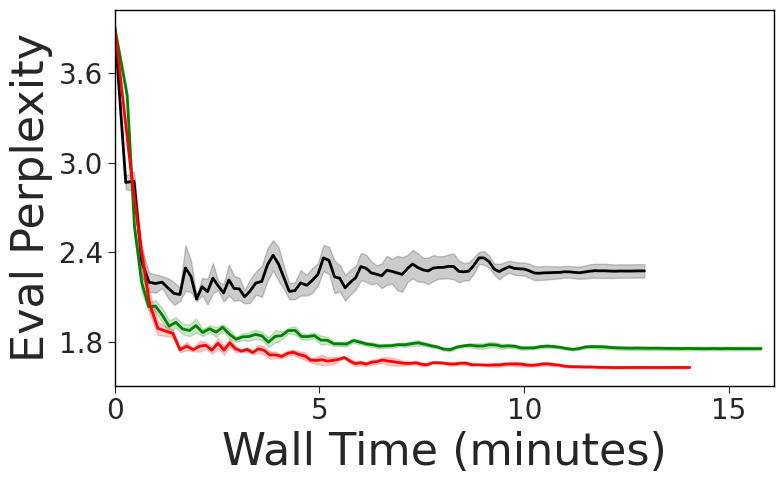


  less_tydiqa

  [less_tydiqa] Full: Eval Perplexity vs Wall Time
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    - FullTraining-Full: no data
    - GlobalSubset-Full: no data
    - LayerWiseSubset-Full: no data


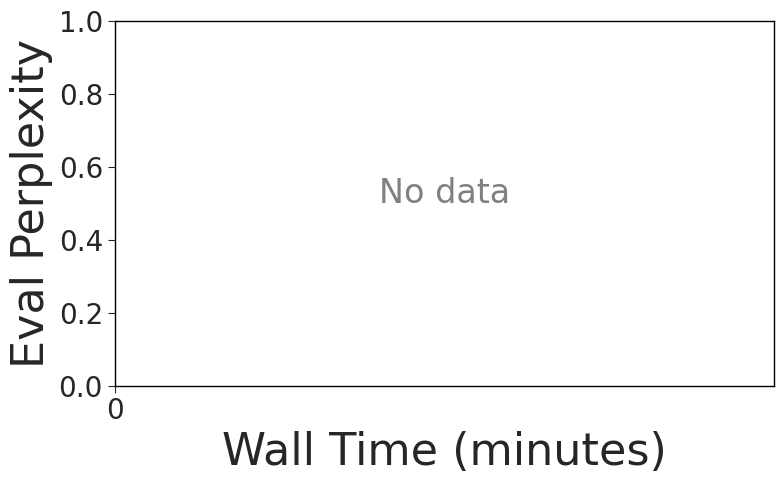


  triviaqa_nq

  [triviaqa_nq] Full: Eval Perplexity vs Wall Time
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 3 seeds, final=11.2862
    + GlobalSubset-Full: 3 seeds, final=10.2603
    + LayerWiseSubset-Full: 3 seeds, final=10.5060


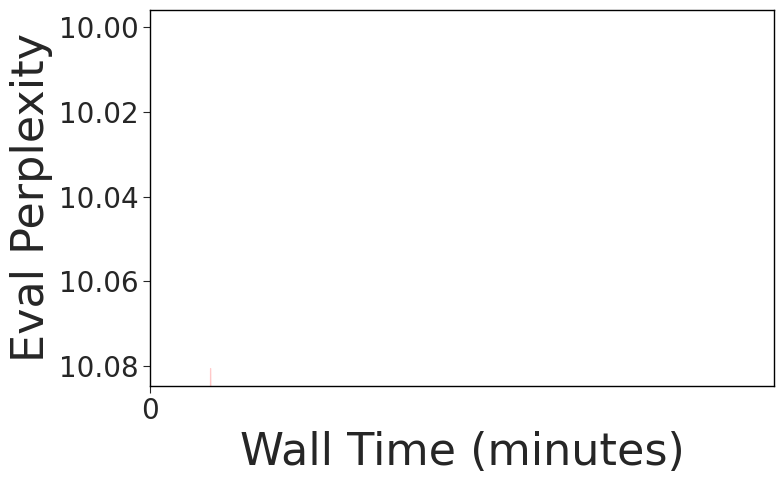


  nq_squad

  [nq_squad] Full: Eval Perplexity vs Wall Time
    Methods: Full-Training, Global Subset, Layer-Wise Subset
    + FullTraining-Full: 3 seeds, final=6.9609
    + GlobalSubset-Full: 3 seeds, final=7.0653
    + LayerWiseSubset-Full: 3 seeds, final=7.1497


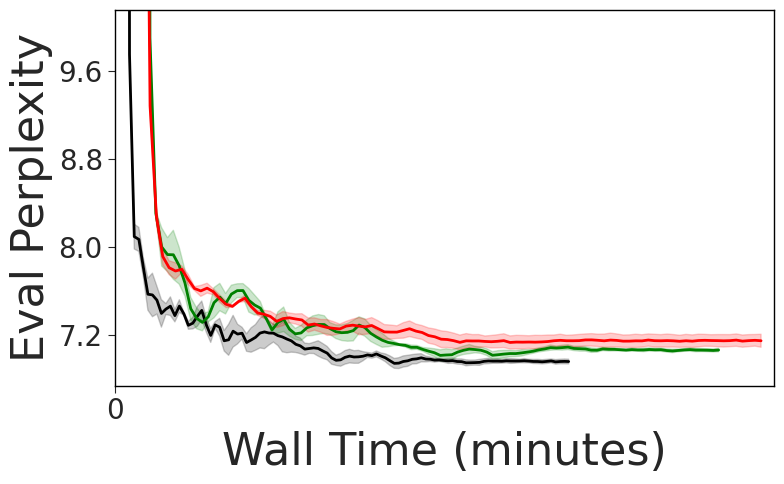

In [15]:
# Paper figures: one per (dataset, finetuning type)
# Each compares Full-Training vs Global Subset vs Layer-Wise Subset on eval perplexity vs wall time
# Uses train_wall_time (eval time subtracted) when available, falls back to wall_time

time_cutoff_minutes = None  # Set to clip x-axis

for ds in DATASETS:
    ds_key = ds['config']
    results = all_results[ds_key]

    print(f"\n{'='*60}")
    print(f"  {ds_key}")
    print(f"{'='*60}")

    # First pass: collect axis ranges across all finetuning groups for this dataset
    all_x_vals, all_y_mins, all_y_maxs = [], [], []
    for ft_name, ft_methods in FINETUNING_GROUPS.items():
        for method_name in ft_methods:
            if method_name not in results:
                continue
            data = results[method_name]
            wt = data['train_wall_time_mean'] if data['train_wall_time_mean'] is not None else data['wall_time_mean']
            if wt is None:
                continue
            all_x_vals.append(wt / 60.0)
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            if data['n_seeds'] > 1:
                all_y_mins.append((mean - std).min())
                all_y_maxs.append((mean + std).max())
            else:
                all_y_mins.append(mean.min())
                all_y_maxs.append(mean.max())

    if all_x_vals:
        shared_x_max = max(v.max() for v in all_x_vals)
        shared_y_min = min(all_y_mins)
        shared_y_max = max(all_y_maxs)
        # Per-dataset y-axis cap: clip outliers (e.g. step=0 baseline on TriviaQA)
        if ds.get('y_clip_max') is not None:
            shared_y_max = min(shared_y_max, ds['y_clip_max'])
        y_pad = (shared_y_max - shared_y_min) * 0.05
    else:
        shared_x_max = shared_y_min = shared_y_max = y_pad = None

    for ft_name, ft_methods in FINETUNING_GROUPS.items():
        print(f"\n  [{ds_key}] {ft_name}: Eval Perplexity vs Wall Time")
        print(f"    Methods: {', '.join(LEGEND_NAMES.get(m, m) for m in ft_methods)}")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')

        has_data = False
        for method_name in ft_methods:
            if method_name not in results:
                print(f"    - {method_name}: no data")
                continue
            data = results[method_name]
            # Prefer train_wall_time (eval time subtracted), fall back to wall_time
            wt = data['train_wall_time_mean'] if data['train_wall_time_mean'] is not None else data['wall_time_mean']
            if wt is None:
                print(f"    - {method_name}: no wall time")
                continue

            x = wt / 60.0
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            color = METHOD_COLORS.get(method_name)
            display = LEGEND_NAMES.get(method_name, method_name)

            ax.plot(x, mean, linewidth=2, label=display, color=color)
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
            has_data = True
            print(f"    + {method_name}: {data['n_seeds']} seeds, final={mean[-1]:.4f}")

        ax.set_xlabel('Wall Time (minutes)', fontsize=32)
        if ft_name == 'Full':
            ax.set_ylabel('Eval Perplexity', fontsize=32)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.xaxis.set_major_locator(MultipleLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        # Enforce shared axis limits across finetuning groups for this dataset
        if shared_x_max is not None:
            ax.set_xlim(left=0, right=time_cutoff_minutes if time_cutoff_minutes is not None else shared_x_max * 1.02)
            ax.set_ylim(shared_y_min - y_pad, shared_y_max + y_pad)

        if not has_data:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=24, color='gray')

        plt.tight_layout()
        plt.show()

## Results Tables: Task-Specific Metrics (All Datasets)

In [16]:
def _fmt(mean, std, n_seeds, fmt_fn=None):
    if mean is None:
        return 'N/A'
    if fmt_fn:
        base = fmt_fn(mean)
    else:
        base = f"{mean:.4f}"
    if n_seeds > 1 and std is not None:
        if '%' in base:
            return f"{mean*100:.1f} +/- {std*100:.1f}%"
        return f"{mean:.4f} +/- {std:.4f}" if fmt_fn is None else f"{mean:.3f} +/- {std:.3f}"
    return base


for ds in DATASETS:
    ds_key = ds['config']
    task_results = all_task_results[ds_key]
    task = ds['task']

    if task_results and task in TASK_METRICS:
        tm = TASK_METRICS[task]
        primary = tm['primary_metric']

        print(f"\n{'='*100}")
        print(f"  {ds_key} ({task.upper()})")
        print(f"{'='*100}")
        header = f"{'Method':<25} {'Seeds':<7}"
        for dn in tm['display_names']:
            header += f" {dn:>18}"
        print(header)
        print("-" * 100)

        for name, data in sorted(task_results.items(),
                                  key=lambda x: x[1].get(f'{primary}_mean', 0) or 0, reverse=True):
            n = data['n_seeds']
            row = f"{name:<25} {n:<7}"
            for metric in tm['metrics']:
                mean = data.get(f'{metric}_mean')
                std = data.get(f'{metric}_std')
                row += f" {_fmt(mean, std, n, tm['format']):>18}"
            print(row)
        print(f"{'='*100}")
        print(f"Loaded {len(task_results)}/{len(ALL_METHODS)} results")
    else:
        print(f"\nNo task-specific results for {ds_key}. Run: bash submit.sh SFT/eval/eval.sh --train {ds['train']} --task {task} --batch_size 32")


  alpaca_samsum (SAMSUM)
Method                    Seeds              ROUGE-1            ROUGE-2            ROUGE-L
----------------------------------------------------------------------------------------------------
LayerWiseSubset-Full      5          0.308 +/- 0.004    0.089 +/- 0.003    0.230 +/- 0.004
GlobalSubset-Full         5          0.252 +/- 0.002    0.063 +/- 0.001    0.184 +/- 0.002
FullTraining-Full         5          0.163 +/- 0.002    0.033 +/- 0.001    0.120 +/- 0.001
Loaded 3/3 results

  tulu3_tydiqa (TYDIQA)
Method                    Seeds             F1 Score        Exact Match
----------------------------------------------------------------------------------------------------
LayerWiseSubset-Full      5         32.831 +/- 1.398   16.960 +/- 1.975
FullTraining-Full         5         26.051 +/- 0.918    1.800 +/- 0.582
GlobalSubset-Full         5         25.363 +/- 1.102   12.320 +/- 1.509
Loaded 3/3 results

No task-specific results for less_tydiqa. Run: bash subm

## Global Comparison vs Step: All Methods + Val-Ablation

Combined 3x2 grid (Full/LoRA/MeSO x SAMSUM/TYDIQA) with val-ablation baselines (dashed blue). X-axis is training step.

Saved: ./figures/global_comparison.pdf


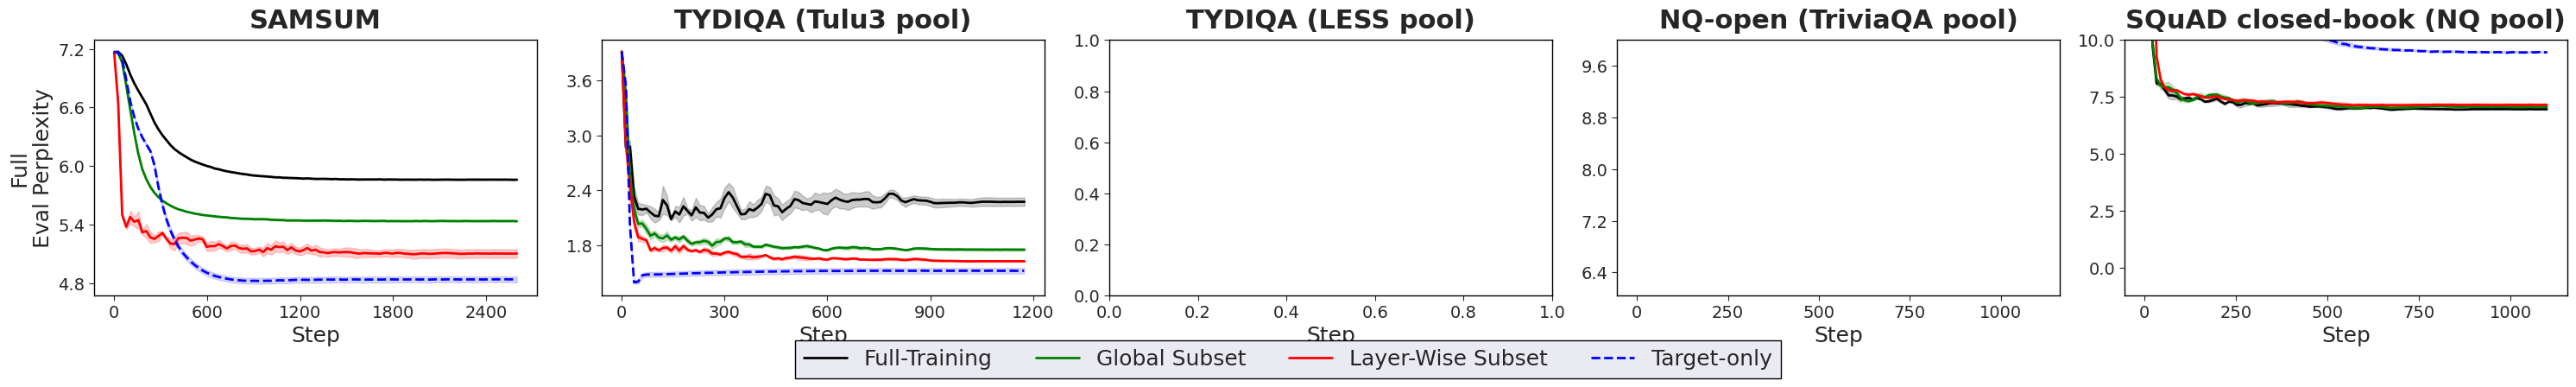

In [17]:
# ============================================
# Global Comparison Grid (Step-based): All Methods + Val-Ablation
# ============================================
# 3 rows (Full, LoRA, MeSO) x 2 columns (SAMSUM, TYDIQA)
# Solid: Full-Training (black), Layer-Wise Subset (red), Global Subset (green)
# Dashed: Target-only (blue)

ncols = len(DATASETS)
nrows = len(FT_ORDER)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
fig.patch.set_facecolor('white')

for col_idx, ds in enumerate(DATASETS):
    ds_key = ds['config']
    results = all_results[ds_key]
    va_results = val_ablation_results.get(ds_key, {})

    for row_idx, ft_name in enumerate(FT_ORDER):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor('white')
        ft_methods = FINETUNING_GROUPS[ft_name]

        # Main methods (solid lines)
        for method_name in ft_methods:
            if method_name not in results:
                continue
            data = results[method_name]
            x = data['steps']
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            color = METHOD_COLORS[method_name]
            label = LEGEND_NAMES[method_name]
            ax.plot(x, mean, linewidth=2, label=label, color=color)
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        # Val-ablation (dashed blue line)
        va_method = f"FullTraining-{ft_name}"
        if va_method in va_results:
            data = va_results[va_method]
            x = data['steps']
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            ax.plot(x, mean, linewidth=2, label='Target-only', color='blue', linestyle='--')
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color='blue', alpha=0.15)

        # Formatting
        if row_idx == 0:
            ax.set_title(DATASET_TITLES.get(ds_key, ds_key), fontsize=22, fontweight='bold', pad=10)
        if row_idx == nrows - 1:
            ax.set_xlabel('Step', fontsize=18)
        if col_idx == 0:
            ax.set_ylabel(f'{ft_name}\nEval Perplexity', fontsize=18)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=14, direction='out', length=4)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

# Enforce shared axis limits per dataset column; also clip y at per-dataset y_clip_max
for col_idx in range(ncols):
    col_axes = [axes[row_idx, col_idx] for row_idx in range(nrows)]
    all_xlims = [ax.get_xlim() for ax in col_axes]
    all_ylims = [ax.get_ylim() for ax in col_axes]
    shared_xlim = (min(l[0] for l in all_xlims), max(l[1] for l in all_xlims))
    shared_ylim = (min(l[0] for l in all_ylims), max(l[1] for l in all_ylims))
    y_cap = DATASETS[col_idx].get('y_clip_max')
    if y_cap is not None:
        shared_ylim = (shared_ylim[0], min(shared_ylim[1], y_cap))
    for ax in col_axes:
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)

# Shared legend at bottom (deduplicated)
handles, labels = [], []
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
seen = {}
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=len(unique_labels),
           fontsize=18, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
filepath = os.path.join(save_dir, 'global_comparison.pdf')
# fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"Saved: {filepath}")
plt.show()

## Global Comparison: All Methods + Val-Ablation

Combined 3x2 grid (Full/LoRA/MeSO x SAMSUM/TYDIQA) with val-ablation baselines (dashed blue). Global table includes all methods + val-ablation results.

KeyError: 'LoRA'

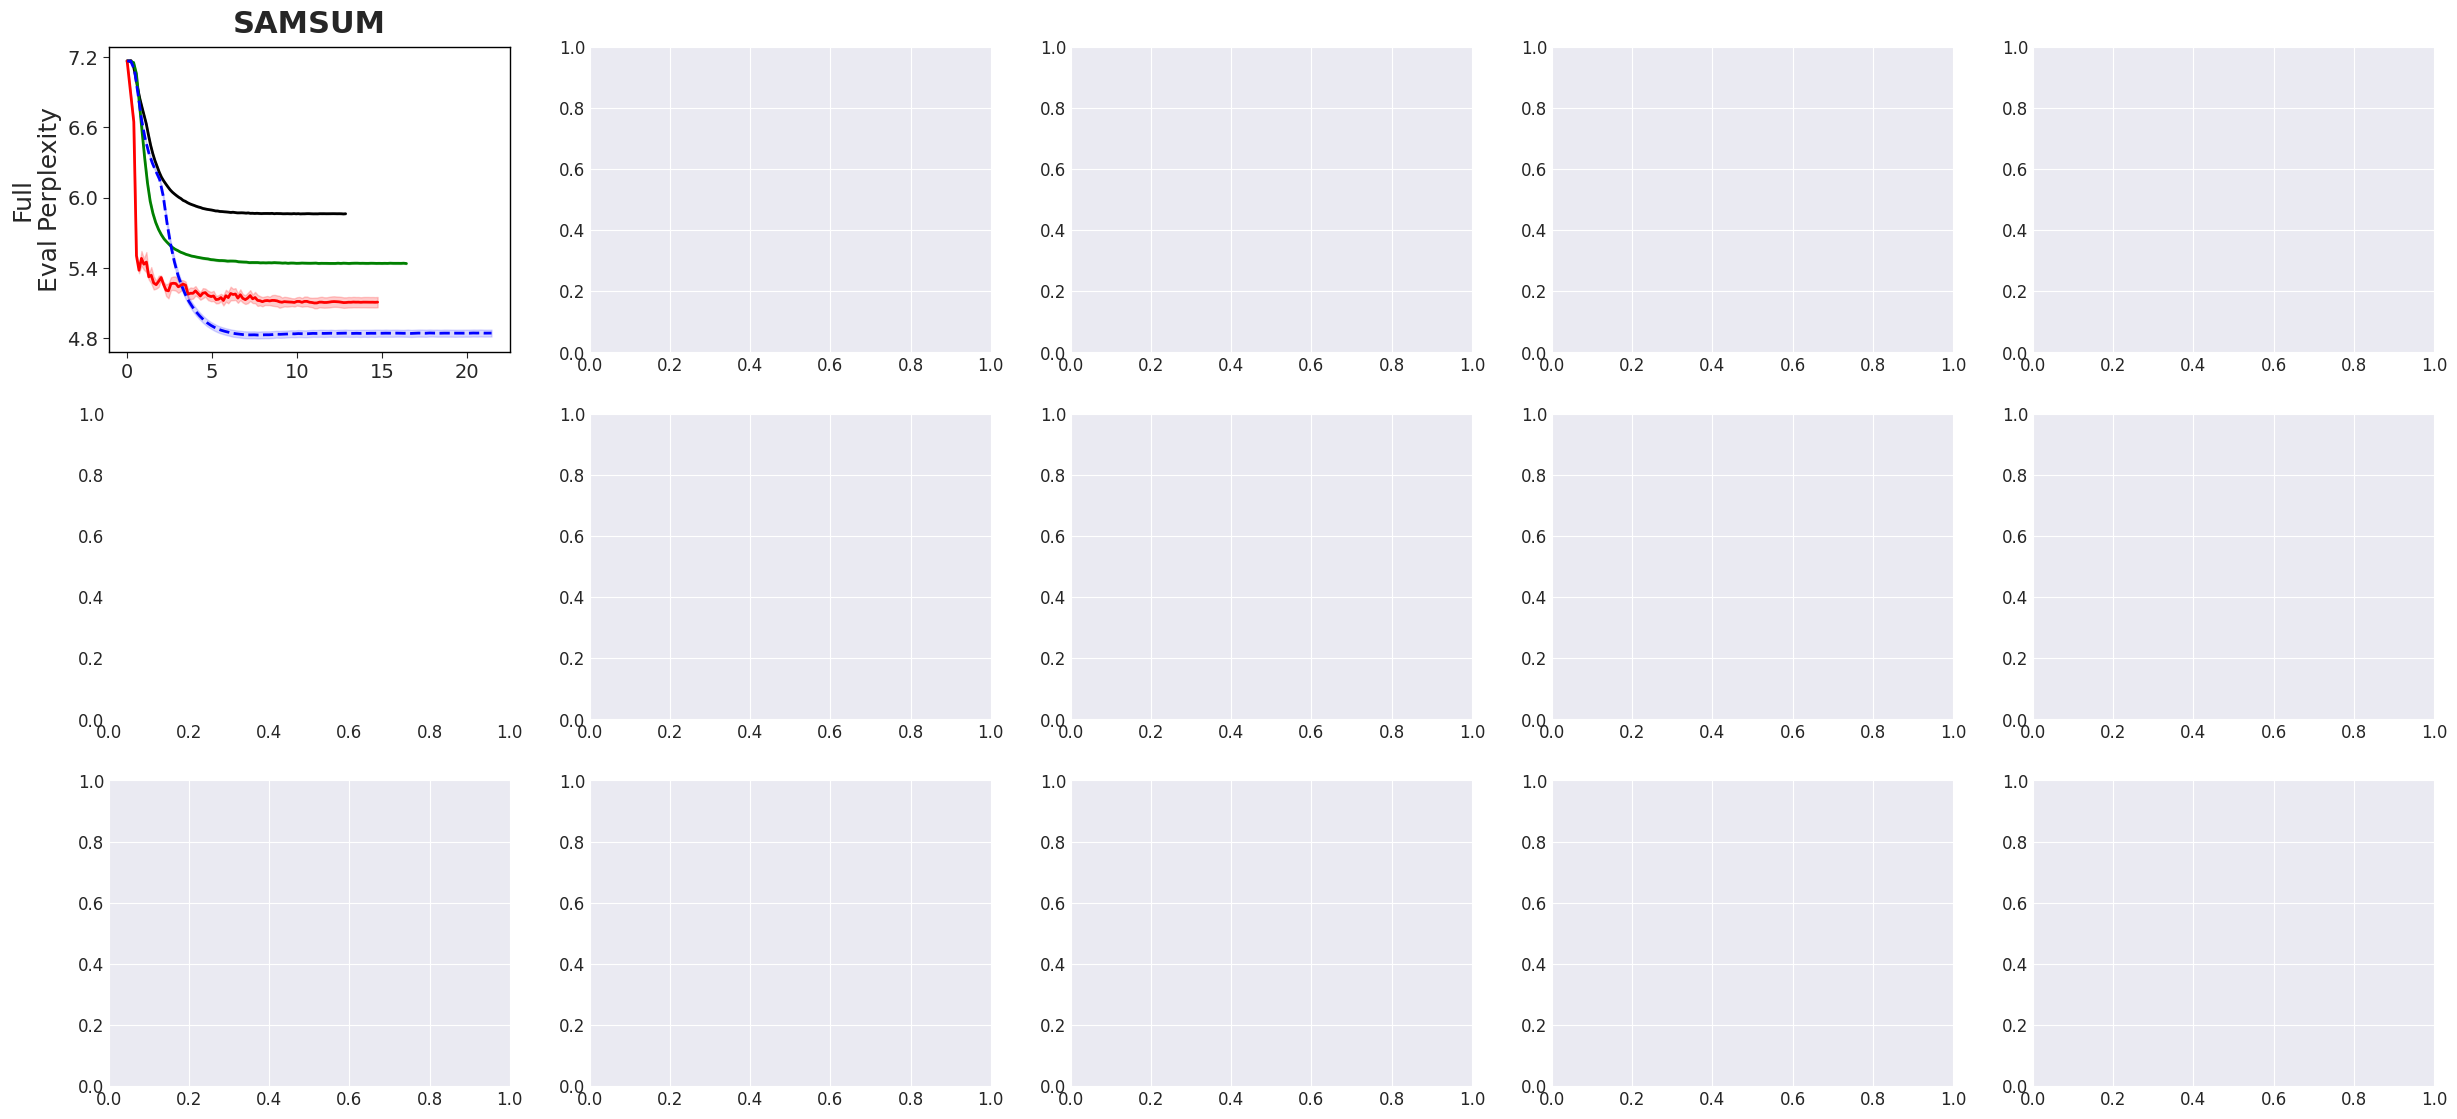

In [18]:
# ============================================
# Global Comparison Grid: All Methods + Val-Ablation
# ============================================
# 3 rows (Full, LoRA, MeSO) x 2 columns (SAMSUM, TYDIQA)
# Solid: Full-Training (black), Layer-Wise Subset (red), Global Subset (green)
# Dashed: Target-only (blue)

DATASET_TITLES = {'alpaca_samsum': 'SAMSUM', 'tulu3_tydiqa': 'TYDIQA'}
FT_ORDER = ['Full', 'LoRA', 'MeSO']

time_cutoff_minutes_global = None

ncols = len(DATASETS)
nrows = len(FT_ORDER)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
fig.patch.set_facecolor('white')

for col_idx, ds in enumerate(DATASETS):
    ds_key = ds['config']
    results = all_results[ds_key]
    va_results = val_ablation_results.get(ds_key, {})

    for row_idx, ft_name in enumerate(FT_ORDER):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor('white')
        ft_methods = FINETUNING_GROUPS[ft_name]

        # Main methods (solid lines)
        for method_name in ft_methods:
            if method_name not in results:
                continue
            data = results[method_name]
            wt = data['train_wall_time_mean'] if data['train_wall_time_mean'] is not None else data['wall_time_mean']
            if wt is None:
                continue
            x = wt / 60.0
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            color = METHOD_COLORS[method_name]
            label = LEGEND_NAMES[method_name]
            ax.plot(x, mean, linewidth=2, label=label, color=color)
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        # Val-ablation (dashed blue line)
        va_method = f"FullTraining-{ft_name}"
        if va_method in va_results:
            data = va_results[va_method]
            wt = data['train_wall_time_mean'] if data['train_wall_time_mean'] is not None else data['wall_time_mean']
            if wt is not None:
                x = wt / 60.0
                mean = data['eval_perplexity_mean']
                std = data['eval_perplexity_std']
                ax.plot(x, mean, linewidth=2, label='Target-only', color='blue', linestyle='--')
                if data['n_seeds'] > 1:
                    ax.fill_between(x, mean - std, mean + std, color='blue', alpha=0.15)

        # Formatting
        if row_idx == 0:
            ax.set_title(DATASET_TITLES.get(ds_key, ds_key), fontsize=22, fontweight='bold', pad=10)
        if row_idx == nrows - 1:
            ax.set_xlabel('Wall Time (minutes)', fontsize=18)
        if col_idx == 0:
            ax.set_ylabel(f'{ft_name}\nEval Perplexity', fontsize=18)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=14, direction='out', length=4)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        if time_cutoff_minutes_global is not None:
            ax.set_xlim(left=0, right=time_cutoff_minutes_global)

# Enforce shared axis limits per dataset column; also clip y at per-dataset y_clip_max
for col_idx in range(ncols):
    col_axes = [axes[row_idx, col_idx] for row_idx in range(nrows)]
    all_xlims = [ax.get_xlim() for ax in col_axes]
    all_ylims = [ax.get_ylim() for ax in col_axes]
    shared_xlim = (min(l[0] for l in all_xlims), max(l[1] for l in all_xlims))
    shared_ylim = (min(l[0] for l in all_ylims), max(l[1] for l in all_ylims))
    y_cap = DATASETS[col_idx].get('y_clip_max')
    if y_cap is not None:
        shared_ylim = (shared_ylim[0], min(shared_ylim[1], y_cap))
    for ax in col_axes:
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)

# Shared legend at bottom (deduplicated)
handles, labels = [], []
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
seen = {}
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=len(unique_labels),
           fontsize=18, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [ ]:
# ============================================
# Global Table: All Methods + Val-Ablation
# ============================================

VA_DISPLAY = {
    'FullTraining-Full': 'Target-only (Full)',
    'FullTraining-LoRA': 'Target-only (LoRA)',
    'FullTraining-MeSO': 'Target-only (MeSO)',
}

for ds in DATASETS:
    ds_key = ds['config']
    task = ds['task']
    main_task = all_task_results.get(ds_key, {})
    va_task = val_ablation_task_results.get(ds_key, {})

    if task not in TASK_METRICS:
        continue
    tm = TASK_METRICS[task]
    primary = tm['primary_metric']

    print(f"\n{'='*100}")
    print(f"  {ds_key} ({task.upper()}) -- All Methods + Val-Ablation")
    print(f"{'='*100}")
    header = f"{'Method':<25} {'Seeds':<7}"
    for dn in tm['display_names']:
        header += f" {dn:>18}"
    print(header)
    print("-" * 100)

    # Main methods sorted by primary metric
    for name, data in sorted(main_task.items(),
                              key=lambda x: x[1].get(f'{primary}_mean', 0) or 0, reverse=True):
        n = data['n_seeds']
        row = f"{name:<25} {n:<7}"
        for metric in tm['metrics']:
            mean = data.get(f'{metric}_mean')
            std = data.get(f'{metric}_std')
            row += f" {_fmt(mean, std, n, tm['format']):>18}"
        print(row)

    # Val-ablation separator + entries
    if va_task:
        print(f"{'- val-ablation ':-<100}")
        for name, data in sorted(va_task.items(),
                                  key=lambda x: x[1].get(f'{primary}_mean', 0) or 0, reverse=True):
            display = VA_DISPLAY.get(name, name)
            n = data['n_seeds']
            row = f"{display:<25} {n:<7}"
            for metric in tm['metrics']:
                mean = data.get(f'{metric}_mean')
                std = data.get(f'{metric}_std')
                row += f" {_fmt(mean, std, n, tm['format']):>18}"
            print(row)

    print(f"{'='*100}")